In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

TICKER   = "ZAMAUSDT"
DATES    = ["2026-04-12", "2026-04-13", "2026-04-14"]
DATA_DIR = Path("../task_data") / TICKER

## 1. Quote Rule — Algorithm

| Condition | Label |
|---|---|
| price < midpoint | `True` — sell aggressor |
| price > midpoint | `False` — buy aggressor |
| price = midpoint | `None` — indeterminate |

In [2]:
all_data = {}
for date in DATES:
    ob = pd.read_parquet(DATA_DIR / f"{TICKER}_orderbook_{date}.parquet")
    tr = pd.read_parquet(DATA_DIR / f"{TICKER}_trades_{date}.parquet")
    mid = ((ob['ask0'] + ob['bid0']) / 2).rename('spread mid point')
    pm = pd.merge_asof(tr, mid.to_frame(), left_index=True, right_index=True, direction='backward')
    all_data[date] = pm[['price', 'spread mid point', 'side']]

{date: len(df) for date, df in all_data.items()}

{'2026-04-12': 31162, '2026-04-13': 32408, '2026-04-14': 578015}

## 2. Multi-Day Evaluation

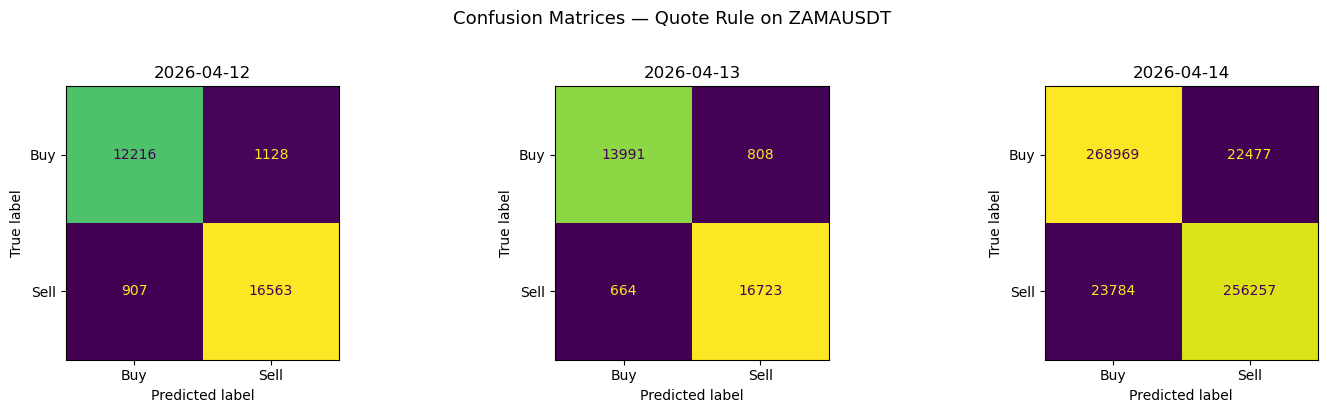

In [3]:
results = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, date in zip(axes, DATES):
    df = all_data[date]
    trade_side = pd.Series(
        np.select(
            [df['price'] < df['spread mid point'], df['price'] > df['spread mid point']],
            [True, False], default=None
        ),
        index=df.index, name='predicted_trade_side'
    )
    final_df = pd.concat([df, trade_side], axis=1).dropna()
    y_true = final_df['side'].astype(bool)
    y_pred  = final_df['predicted_trade_side'].astype(bool)
    results[date] = (y_true, y_pred, len(df) - len(final_df))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=['Buy', 'Sell'], colorbar=False, ax=ax
    )
    ax.set_title(date)

fig.suptitle(f'Confusion Matrices — Quote Rule on {TICKER}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Per-Day Classification Reports

In [4]:
for date, (y_true, y_pred, indet) in results.items():
    print(f"\n=== {date}  (indeterminate: {indet}) ===")
    print(classification_report(y_true, y_pred, target_names=['Buy (False)', 'Sell (True)']))


=== 2026-04-12  (indeterminate: 348) ===
              precision    recall  f1-score   support

 Buy (False)       0.93      0.92      0.92     13344
 Sell (True)       0.94      0.95      0.94     17470

    accuracy                           0.93     30814
   macro avg       0.93      0.93      0.93     30814
weighted avg       0.93      0.93      0.93     30814


=== 2026-04-13  (indeterminate: 222) ===
              precision    recall  f1-score   support

 Buy (False)       0.95      0.95      0.95     14799
 Sell (True)       0.95      0.96      0.96     17387

    accuracy                           0.95     32186
   macro avg       0.95      0.95      0.95     32186
weighted avg       0.95      0.95      0.95     32186


=== 2026-04-14  (indeterminate: 6528) ===
              precision    recall  f1-score   support

 Buy (False)       0.92      0.92      0.92    291446
 Sell (True)       0.92      0.92      0.92    280041

    accuracy                           0.92    571487
 

## 4. Summary

In [5]:
records = []
for date, (y_true, y_pred, indet) in results.items():
    r = classification_report(y_true, y_pred, target_names=['Buy', 'Sell'], output_dict=True)
    records.append({
        'Date': date, 'Samples': len(y_true), 'Indeterminate': indet,
        'Accuracy': r['accuracy'],
        'Buy F1': r['Buy']['f1-score'],
        'Sell F1': r['Sell']['f1-score'],
        'Macro F1': r['macro avg']['f1-score'],
    })

pd.DataFrame(records).set_index('Date').style \
    .format({'Accuracy': '{:.4f}', 'Buy F1': '{:.4f}', 'Sell F1': '{:.4f}', 'Macro F1': '{:.4f}'}) \
    .highlight_max(subset=['Accuracy', 'Buy F1', 'Sell F1', 'Macro F1'], color='lightgreen')

,Samples,Indeterminate,Accuracy,Buy F1,Sell F1,Macro F1
Date,,,,,,
2026-04-12,30814,348,0.9340,0.9231,0.9421,0.9326
2026-04-13,32186,222,0.9543,0.9500,0.9578,0.9539
2026-04-14,571487,6528,0.9191,0.9208,0.9172,0.9190
